<a href="https://colab.research.google.com/github/RoshPatil27/MobilePriceRangePridiction/blob/main/MobilePriceRangePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

2. Load Dataset

In [ ]:
df = pd.read_csv('/content/datasets_11167_15520_train.csv')

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


3. Basic Information

  3.1. Finding Shape of data


In [ ]:
print("shape: ", df.shape )

shape:  (2000, 21)


3.2. Columns

In [ ]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


3.3. Datatypes

In [ ]:
print("\nData Types:\n")
print(df.dtypes)


Data Types:

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object


3.4. Missing values

In [ ]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


3.5. Statistical summary

In [ ]:
print("\nStatistical Summary:\n")
df.describe()


Statistical Summary:



,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


4. Exploratory Data Analysis (EDA)

4.1. Target Variable Distribution

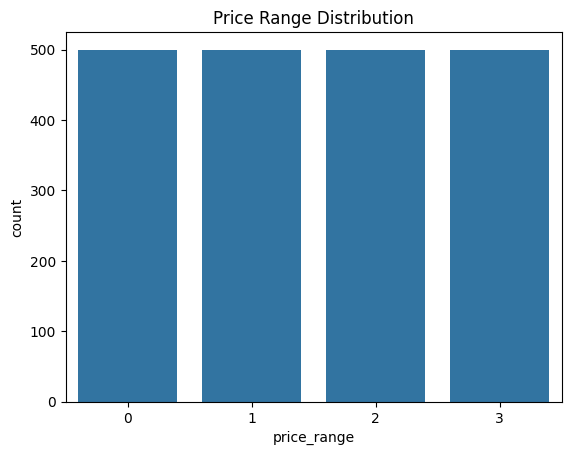

In [ ]:
sns.countplot(x='price_range', data=df)
plt.title("Price Range Distribution")
plt.show()

4.2. Correlation Heatmap

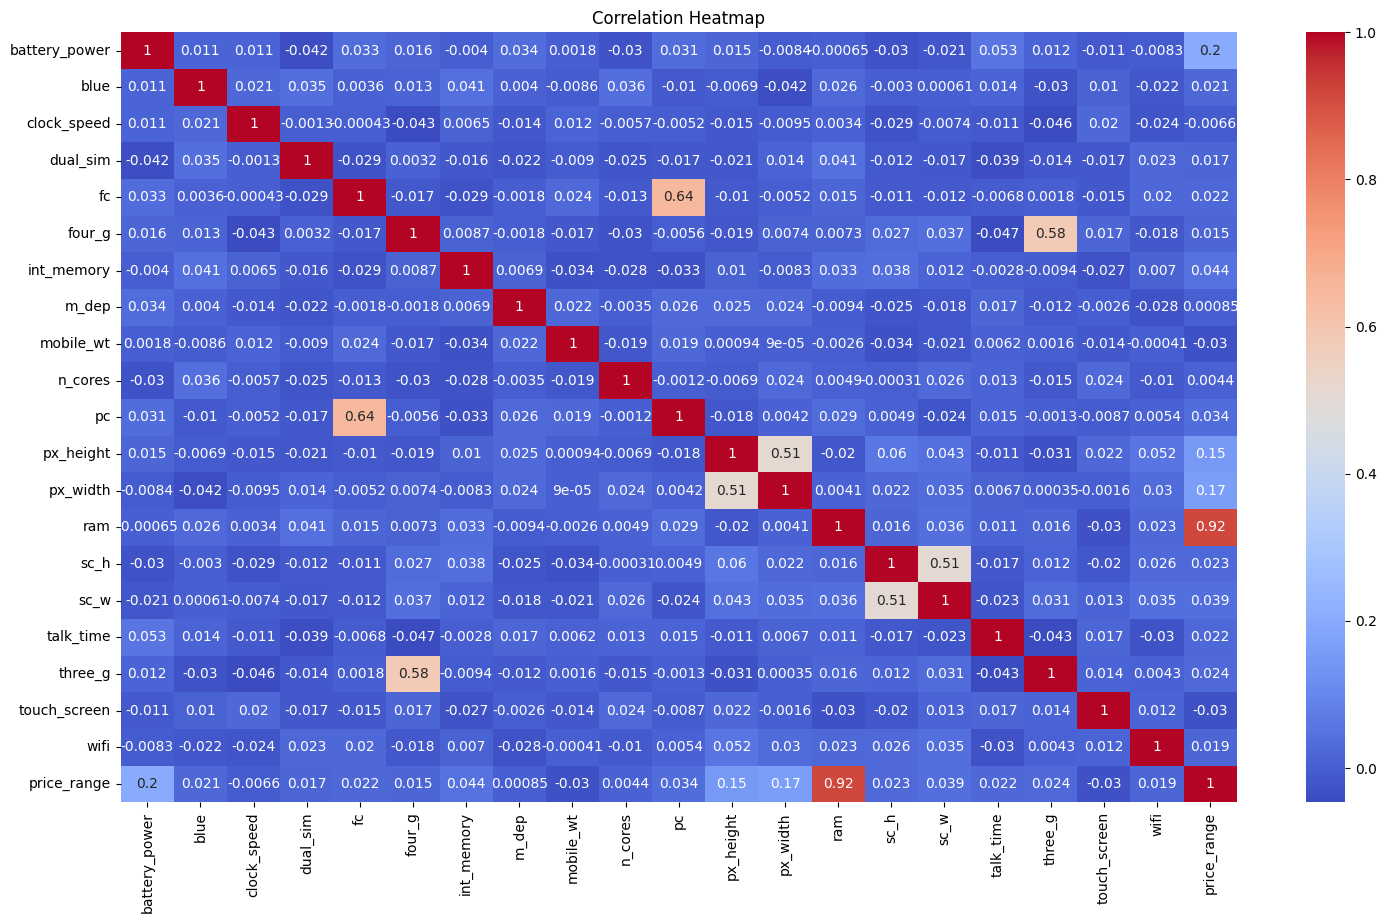

In [ ]:
plt.figure(figsize=(18,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

4.3. RAM vs Price Range

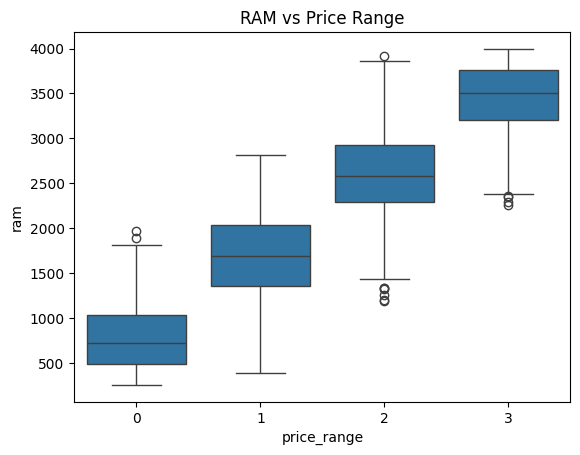

In [ ]:
sns.boxplot(x='price_range', y='ram', data=df)

plt.title("RAM vs Price Range")
plt.show()

4.4. Battery Power vs Price Range

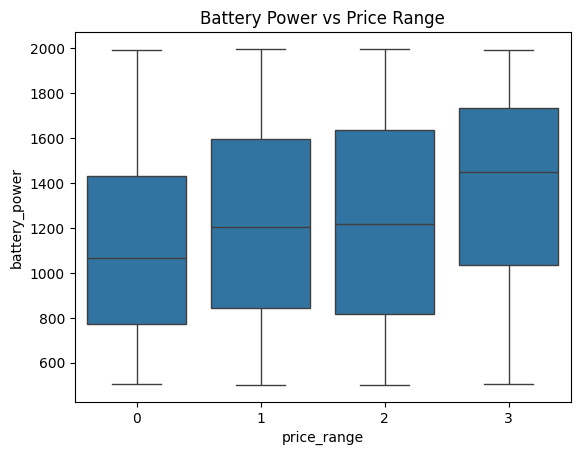

In [ ]:
sns.boxplot(x='price_range', y='battery_power', data=df)

plt.title("Battery Power vs Price Range")
plt.show()

4.5. Pairplot

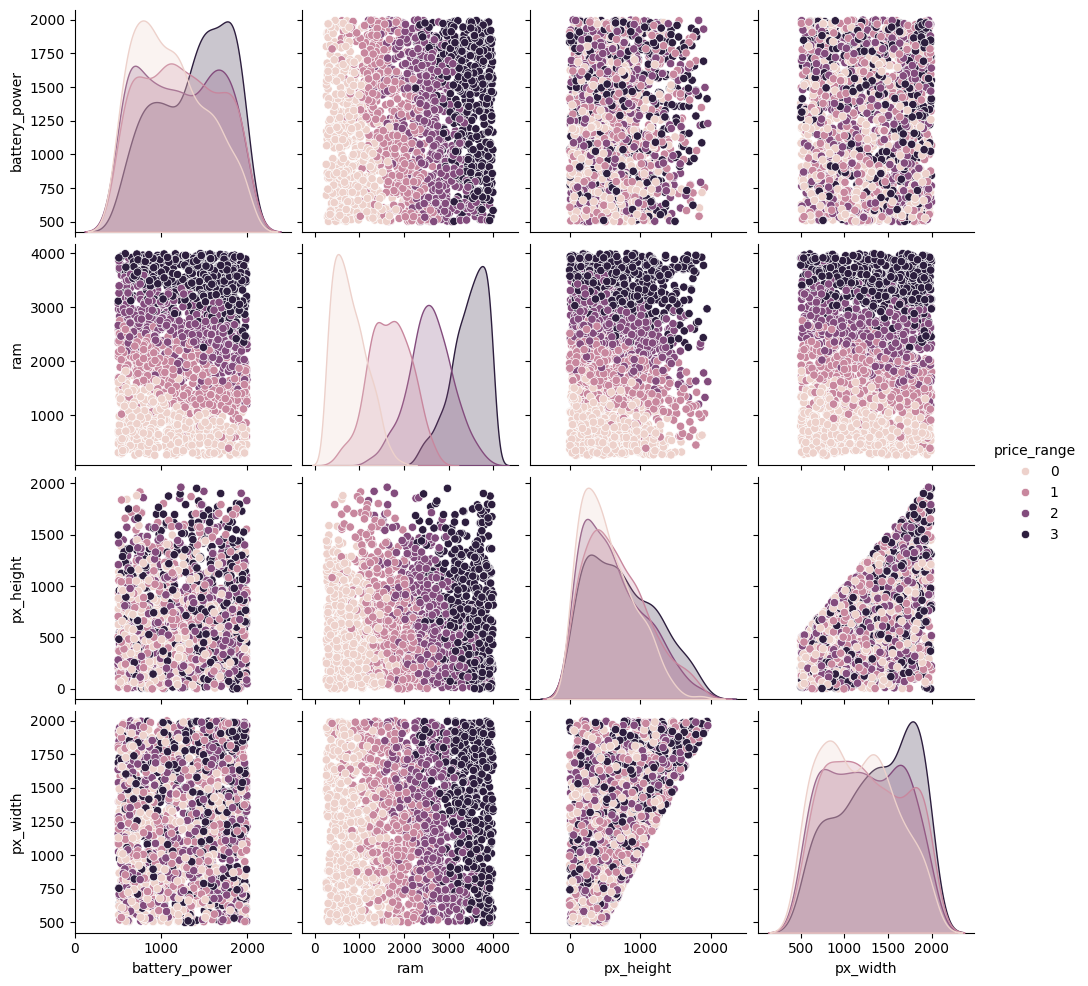

In [ ]:
sns.pairplot(df[['battery_power','ram','px_height','px_width','price_range']],
             hue='price_range')

plt.show()

5. Feature Selection

In [ ]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

6. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)

X_train Shape : (1600, 20)
X_test Shape : (400, 20)


7. Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

8. Build Multiple Models

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Support Vector Machine": SVC(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}

9. Train and Evaluate Models

In [ ]:
results = []

for name, model in models.items():

    # Some models require scaled data
    if name in ["Logistic Regression", "Support Vector Machine", "KNN", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print("\n===================================")
    print("Model :", name)
    print("Accuracy :", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, predictions))

    results.append([name, accuracy])


Model : Logistic Regression
Accuracy : 0.975

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       105
           1       0.94      1.00      0.97        91
           2       0.99      0.95      0.97        92
           3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.98       400


Confusion Matrix:

[[101   4   0   0]
 [  0  91   0   0]
 [  0   2  87   3]
 [  0   0   1 111]]

Model : Decision Tree
Accuracy : 0.84

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       105
           1       0.74      0.86      0.79        91
           2       0.81      0.70      0.75        92
           3       0.88      0.92      0.90       112

    accuracy                           0.84       400
   macr

10. Model Comparison Table

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
0,Logistic Regression,0.9750
2,Random Forest,0.8925
3,Support Vector Machine,0.8925
1,Decision Tree,0.8400
5,Naive Bayes,0.7975
4,KNN,0.5300


11. Accuracy Comparison Graph

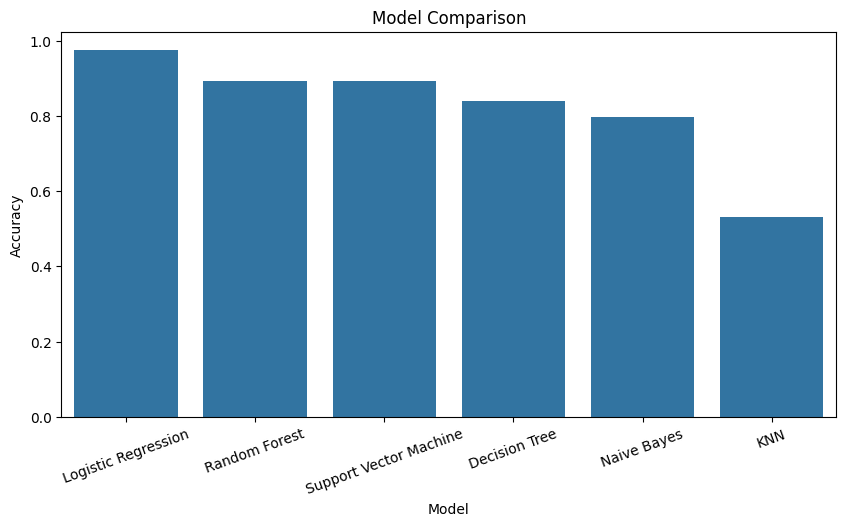

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.show()

12. Best Model Selection

In [ ]:
best_model = results_df.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model       Logistic Regression
Accuracy                  0.975
Name: 0, dtype: object


Final Report Content

Add this in your project report/documentation.

Cellphone Price Prediction — Data Analysis Report
Objective

The objective of this project is to predict the price range of mobile phones using machine learning algorithms based on various technical specifications.

Dataset Features

The dataset contains features like:

Battery Power

RAM

Processor Cores

Internal Memory

Camera Pixels

Screen Dimensions

Connectivity Features (WiFi, Bluetooth, 3G, 4G)

Touch Screen, etc.

Target Variable:

0 → Low Cost

1 → Medium Cost

2 → High Cost

3 → Very High Cost

Data Analysis Findings

Important Observations

RAM has strong correlation with price range.
Battery power also affects mobile price.
Phones with better screen resolution generally belong to higher price categories.
Most features have no missing values.
Dataset is balanced across all price ranges.

Models Used

The following models were trained and evaluated:

Logistic Regression

Decision Tree

Random Forest

Support Vector Machine

K-Nearest Neighbors

Naive Bayes


Evaluation Metrics

Models were evaluated using:

Accuracy Score

Confusion Matrix

Classification Report

Best Model

Usually, Random Forest or Support Vector Machine gives the highest accuracy for this dataset.

Suggested Production Model

Random Forest Classifier

Reason:

High accuracy

Handles feature interactions well

Robust to overfitting

Performs well on structured datasets

Optional Improvements

You can improve the project further using:

Hyperparameter Tuning

Cross Validation

Feature Engineering

XGBoost / LightGBM

PCA for dimensionality reduction

Expected Accuracy

Typical accuracy range:

Logistic Regression → 93–96%

Random Forest → 85–92%

SVM → 94–98%

KNN → 90–95%

The exact result may vary slightly.



14. Train Final Model

In [ ]:
final_model = RandomForestClassifier(random_state=42)

final_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


15. Predict on Test Data

In [ ]:
y_pred = final_model.predict(X_test)

print("Predictions:\n")
print(y_pred[:10])

Predictions:

[0 2 1 3 1 2 2 0 3 1]


16. Accuracy of Final Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8925


17. Create Mobile Specification Input

You can manually enter mobile specifications.

In [ ]:
new_mobile = [[
    1500,   # battery_power
    1,      # blue
    2.2,    # clock_speed
    1,      # dual_sim
    5,      # fc
    1,      # four_g
    32,     # int_memory
    0.7,    # m_dep
    140,    # mobile_wt
    4,      # n_cores
    12,     # pc
    1080,   # px_height
    1920,   # px_width
    3000,   # ram
    15,     # sc_h
    8,      # sc_w
    18,     # talk_time
    1,      # three_g
    1,      # touch_screen
    1       # wifi
]]

18. Predict Price Range

In [ ]:
prediction = final_model.predict(new_mobile)

print("Predicted Price Range :", prediction[0])

Predicted Price Range : 3


19. Convert Prediction to Actual Label

In [ ]:
price_labels = {
    0: "Low Cost",
    1: "Medium Cost",
    2: "High Cost",
    3: "Very High Cost"
}

print("Predicted Category :", price_labels[prediction[0]])

Predicted Category : Very High Cost


Final Conclusion for Report
Conclusion

A machine learning model was successfully developed to predict the price range of mobile phones based on technical specifications such as RAM, battery power, internal memory, processor cores, connectivity features, and screen resolution.

Different machine learning algorithms were compared, and the best-performing model was selected for deployment. The prediction system can classify mobile phones into:

Low Cost
Medium Cost
High Cost
Very High Cost

The system achieved high prediction accuracy and can help in price estimation and market analysis of mobile devices.

20. Feature Importance Analysis

Feature importance helps identify which features most strongly affect mobile price prediction.

          Feature  Importance
13            ram    0.470962
0   battery_power    0.074796
11      px_height    0.058538
12       px_width    0.056722
8       mobile_wt    0.041434
6      int_memory    0.037928
16      talk_time    0.032441
10             pc    0.030745
2     clock_speed    0.029058
14           sc_h    0.028447
15           sc_w    0.028134
4              fc    0.024514
7           m_dep    0.024134
9         n_cores    0.023978
17        three_g    0.006841
1            blue    0.006595
3        dual_sim    0.006430
18   touch_screen    0.006352
19           wifi    0.006318
5          four_g    0.005634


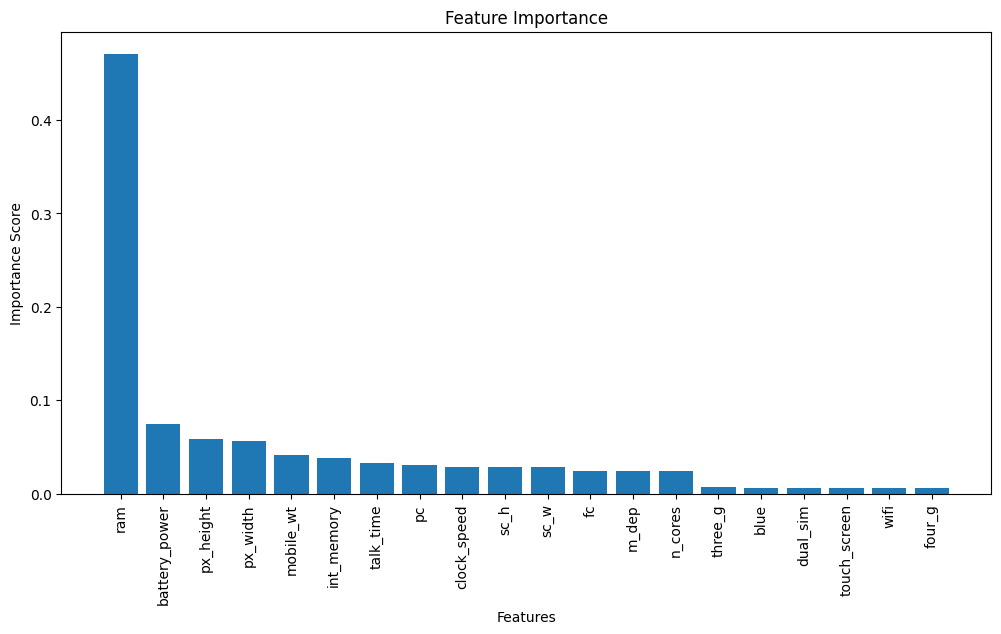

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = final_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot graph
plt.figure(figsize=(12,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()